Base carregada com sucesso.
Total de registros: 1020
Período: 2023-07-01 a 2026-04-15
        Data  Sessões  Usuários ativos  Visualizações  dia_semana  \
0 2023-07-01     3109             2047           5566           6   
1 2023-07-02     3099             2083           5498           7   
2 2023-07-03    24119            13516          46786           1   
3 2023-07-04    23635            13335          44984           2   
4 2023-07-05    22217            13014          43559           3   

   fim_de_semana  mes  recesso_judiciario  feriado_nacional_fixo  carnaval  \
0              1    7                   0                      0         0   
1              1    7                   0                      0         0   
2              0    7                   0                      0         0   
3              0    7                   0                      0         0   
4              0    7                   0                      0         0   

   quarta_cinzas  sexta_paixao

FileNotFoundError: [Errno 2] No such file or directory: '../resultados/sarimax_real_vs_previsto.png'

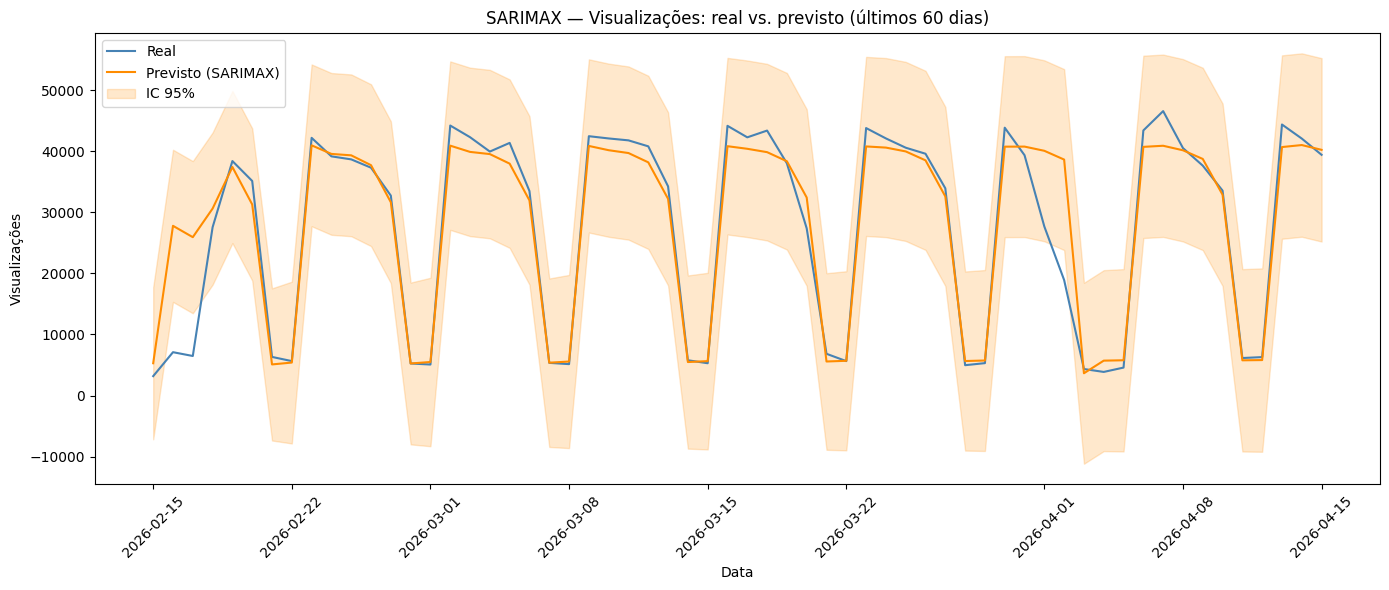

In [1]:
# %%
# %% [markdown]
# ## 1. Geração da base específica para o SARIMAX
#
# A base geral tratada é carregada a partir do arquivo `trafego_tratado.csv`.
# Para o SARIMAX, a variável-alvo é `Visualizações`, acrescida de variáveis externas
# conhecidas antecipadamente: datas de calendário institucional e dummies de dia da semana.
#
# `Sessões` e `Usuários ativos` foram excluídas: seus valores futuros não seriam
# conhecidos em situação real de previsão.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

df = pd.read_csv("../dados/trafego_tratado.csv")
df["Data"] = pd.to_datetime(df["Data"])
df = df.sort_values("Data").reset_index(drop=True)

print("Base carregada com sucesso.")
print(f"Total de registros: {len(df)}")
print(f"Período: {df['Data'].min().date()} a {df['Data'].max().date()}")
print(df.head())


# %% [markdown]
# ## 2. Verificação de estacionariedade
#
# Aplica-se o teste ADF (Augmented Dickey-Fuller) e o KPSS sobre a série de
# Visualizações para definir se diferenciação (d > 0 ou D > 0) é necessária.
#
# - ADF: H0 = série tem raiz unitária (não estacionária). Rejeitar H0 (p < 0,05) indica estacionariedade.
# - KPSS: H0 = série é estacionária. Rejeitar H0 (p < 0,05) indica não estacionariedade.
#
# Ambos concordando em "estacionária" justifica d=0 e D=0 no grid search.

# %%
y_full = df["Visualizações"]

adf_stat, adf_p, _, _, _, _ = adfuller(y_full, autolag="AIC")
kpss_stat, kpss_p, _, _     = kpss(y_full, regression="c", nlags="auto")

print("=" * 55)
print("TESTE DE ESTACIONARIEDADE — SÉRIE ORIGINAL")
print("=" * 55)
print(f"ADF  | Estatística: {adf_stat:.4f} | p-valor: {adf_p:.4f}")
print(f"       {'Estacionária (rejeita H0)' if adf_p < 0.05 else 'Não estacionária (não rejeita H0)'}")
print()
print(f"KPSS | Estatística: {kpss_stat:.4f} | p-valor: {kpss_p:.4f}")
print(f"       {'Não estacionária (rejeita H0)' if kpss_p < 0.05 else 'Estacionária (não rejeita H0)'}")
print()

if adf_p < 0.05 and kpss_p >= 0.05:
    d_recomendado = 0
    print("Ambos os testes indicam ESTACIONARIEDADE. Adotado: d=0, D=0.")
elif adf_p >= 0.05 or kpss_p < 0.05:
    d_recomendado = 1
    print("Indício de NÃO ESTACIONARIEDADE. Adotado: d=1.")
    print("Considere incluir D=1 nas ordens sazonais também.")
else:
    d_recomendado = 0
    print("Testes divergem. Adotado d=0 como padrão conservador.")

print(f"\nd adotado no grid search: {d_recomendado}")


# %% [markdown]
# ## 3. Seleção da série temporal e dos regressores externos
#
# Os regressores externos combinam:
# - Variáveis de calendário institucional (recesso, feriados, carnaval, etc.)
# - Dummies de dia da semana (dia_2 a dia_7, referência = segunda-feira)
#
# **Decisão importante:** `fim_de_semana` foi excluída deliberadamente.
# Essa variável é combinação linear exata de `dia_6 + dia_7`, gerando
# colinearidade perfeita que torna a matriz de regressores singular.
# A informação de sábado e domingo já está capturada pelas dummies `dia_6` e `dia_7`.
#
# **Diferenciação sazonal (D):** como a série é estacionária (testes ADF e KPSS),
# D=0 é o ponto de partida. Com D=1, as dummies de dia da semana perdem significância
# porque a diferenciação sazonal S=7 já remove o padrão intra-semanal — tornando
# as dummies redundantes. Por isso, o grid search prioriza configurações com D=0.

# %%
dummies_dia = pd.get_dummies(df["dia_semana"], prefix="dia", drop_first=True).astype(int)

colunas_calendario = [
    "recesso_judiciario",
    "feriado_nacional_fixo",
    "carnaval",
    "quarta_cinzas",
    "sexta_paixao",
    "corpus_christi",
    "data_especifica_judiciario",
    "ponto_facultativo_emenda"
]

df_exog = pd.concat([df[colunas_calendario], dummies_dia], axis=1)
df_sarimax = pd.concat([df[["Data", "Visualizações"]], df_exog], axis=1)
df_sarimax = df_sarimax.set_index("Data").asfreq("D")

colunas_exog = colunas_calendario + list(dummies_dia.columns)

assert df_sarimax.isna().sum().sum() == 0, "Há valores ausentes na base SARIMAX."

print("Base SARIMAX criada com sucesso.")
print(f"Regressores externos utilizados ({len(colunas_exog)}):")
for c in colunas_exog:
    print(f"  - {c}")


# %% [markdown]
# ## 4. Separação temporal entre treino e teste
#
# Os últimos 60 dias foram reservados para teste. A divisão é estritamente temporal,
# sem embaralhamento, preservando a ordem cronológica da série.

# %%
dias_teste = 60

y = df_sarimax["Visualizações"]
X = df_sarimax[colunas_exog]

y_train = y.iloc[:-dias_teste]
y_test  = y.iloc[-dias_teste:]
X_train = X.iloc[:-dias_teste]
X_test  = X.iloc[-dias_teste:]

assert X_test.isna().sum().sum() == 0, "Há NaN nas exógenas do período de teste."

print("Separação treino/teste realizada com sucesso.")
print(f"Registros de treino: {len(y_train)}")
print(f"Registros de teste : {len(y_test)}")
print(f"Período de teste   : {y_test.index.min().date()} a {y_test.index.max().date()}")


# %% [markdown]
# ## 5. Grid search de hiperparâmetros do SARIMAX
#
# O espaço de busca cobre:
# - Ordens ARIMA (p, d, q): d fixado pelo teste de estacionariedade (seção 2);
#   p e q de 0 a 2 (9 combinações).
# - Ordens sazonais (P, D, Q, S=7): D=0 pois a série é estacionária e as dummies
#   de dia capturam a sazonalidade semanal de forma mais interpretável;
#   P e Q de 0 a 2 (9 combinações).
# - Total: até 81 combinações testadas.
#
# A seleção usa **RMSE no conjunto de teste** como critério principal, pois o objetivo
# é desempenho preditivo. O AIC é registrado como critério complementar de parcimônia.
#
# Nota: `enforce_stationarity=False` e `enforce_invertibility=False` ampliam o
# espaço de busca na fase exploratória. O modelo final terá raízes inspecionadas
# para verificar estabilidade (seção 6).

# %%
p_vals = [0, 1, 2]
q_vals = [0, 1, 2]
d_val  = d_recomendado

P_vals = [0, 1, 2]
D_val  = 0   # D=0: série estacionária; D=1 tornaria dummies de dia redundantes
Q_vals = [0, 1, 2]
S_val  = 7

melhor_rmse          = np.inf
melhor_ordem         = None
melhor_ordem_sazonal = None
melhor_modelo        = None
resultados_grid      = []

total = len(p_vals) * len(q_vals) * len(P_vals) * len(Q_vals)
print(f"Testando até {total} combinações (D={D_val}, S={S_val})...\n")

for p in p_vals:
    for q in q_vals:
        ordem = (p, d_val, q)
        for P in P_vals:
            for Q in Q_vals:
                ordem_sazonal = (P, D_val, Q, S_val)
                try:
                    modelo = SARIMAX(
                        y_train,
                        exog=X_train,
                        order=ordem,
                        seasonal_order=ordem_sazonal,
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    )
                    resultado = modelo.fit(disp=False, maxiter=500)

                    # Calcular RMSE no teste para seleção
                    pred_teste = resultado.get_forecast(
                        steps=dias_teste, exog=X_test
                    ).predicted_mean
                    rmse_teste = np.sqrt(mean_squared_error(y_test, pred_teste))

                    resultados_grid.append({
                        "ordem": ordem,
                        "sazonal": ordem_sazonal,
                        "aic": resultado.aic,
                        "bic": resultado.bic,
                        "rmse_teste": rmse_teste
                    })

                    if rmse_teste < melhor_rmse:
                        melhor_rmse          = rmse_teste
                        melhor_ordem         = ordem
                        melhor_ordem_sazonal = ordem_sazonal
                        melhor_modelo        = resultado

                except Exception:
                    pass

df_grid = pd.DataFrame(resultados_grid).sort_values("rmse_teste").reset_index(drop=True)

print("Top 10 configurações por RMSE no teste:")
print(df_grid.head(10).to_string(index=False))

print(f"\nMelhor configuração (menor RMSE no teste):")
print(f"  Ordem         : {melhor_ordem}")
print(f"  Ordem sazonal : {melhor_ordem_sazonal}")
print(f"  RMSE (teste)  : {melhor_rmse:.2f}")
print(f"  AIC           : {df_grid.iloc[0]['aic']:.2f}")


# %% [markdown]
# ## 6. Diagnóstico do modelo selecionado
#
# Verifica-se:
# 1. Resumo estatístico: coeficientes, p-valores e significância das variáveis.
# 2. Raízes AR e MA: módulos > 1 indicam modelo estável e invertível.
#    Raízes com módulo próximo de 1 sinalizam risco de instabilidade.

# %%
print(melhor_modelo.summary())

try:
    raizes_ar = melhor_modelo.arroots
    raizes_ma = melhor_modelo.maroots
    if len(raizes_ar) > 0:
        modulos_ar = np.abs(raizes_ar).round(4)
        print(f"\nRaízes AR (módulos): {modulos_ar}")
        print(f"  {'Todas > 1 — modelo estável' if all(modulos_ar > 1) else 'ATENÇÃO: raiz(es) com módulo <= 1 — verificar estabilidade'}")
    if len(raizes_ma) > 0:
        modulos_ma = np.abs(raizes_ma).round(4)
        print(f"Raízes MA (módulos): {modulos_ma}")
        print(f"  {'Todas > 1 — modelo invertível' if all(modulos_ma > 1) else 'ATENÇÃO: raiz(es) com módulo <= 1 — verificar invertibilidade'}")
except Exception:
    print("Não foi possível extrair raízes automaticamente. Verifique o summary() acima.")


# %% [markdown]
# ## 7. Previsão no conjunto de teste
#
# O modelo selecionado gera previsões pontuais e intervalos de confiança (95%)
# para os 60 dias de teste, utilizando os regressores externos do período.

# %%
previsao_sarimax = melhor_modelo.get_forecast(steps=dias_teste, exog=X_test)
y_pred_sarimax   = previsao_sarimax.predicted_mean
intervalo_conf   = previsao_sarimax.conf_int()

print("Previsão realizada com sucesso.")
print(y_pred_sarimax.head())


# %% [markdown]
# ## 8. Avaliação do SARIMAX
#
# Métricas calculadas no conjunto de teste: RMSE, MAE, MAPE e R².
#
# O MAPE exclui dias com valor real zero (divisão por zero). O número de dias
# excluídos é reportado para garantir transparência na comparação entre modelos.

# %%
def calcular_mape(y_true, y_pred):
    y_true      = np.array(y_true, dtype=float)
    y_pred      = np.array(y_pred, dtype=float)
    mascara     = y_true != 0
    n_excluidos = (~mascara).sum()
    if n_excluidos > 0:
        print(f"  Aviso MAPE: {n_excluidos} dia(s) com valor real = 0 excluído(s) do cálculo.")
    return np.mean(np.abs((y_true[mascara] - y_pred[mascara]) / y_true[mascara])) * 100

rmse_sarimax = np.sqrt(mean_squared_error(y_test, y_pred_sarimax))
mae_sarimax  = mean_absolute_error(y_test, y_pred_sarimax)
mape_sarimax = calcular_mape(y_test, y_pred_sarimax)
r2_sarimax   = r2_score(y_test, y_pred_sarimax)

print("=" * 55)
print("AVALIAÇÃO SARIMAX — ÚLTIMOS 60 DIAS")
print("=" * 55)
print(f"Ordem         : {melhor_ordem}")
print(f"Ordem sazonal : {melhor_ordem_sazonal}")
print(f"RMSE  : {rmse_sarimax:.2f}")
print(f"MAE   : {mae_sarimax:.2f}")
print(f"MAPE  : {mape_sarimax:.2f}%")
print(f"R²    : {r2_sarimax:.4f}")


# %% [markdown]
# ## 9. Visualização dos valores reais e previstos pelo SARIMAX
#
# Gráfico comparando valores reais, previstos e intervalo de confiança de 95%.

# %%
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test.values, label="Real", color="steelblue")
plt.plot(y_test.index, y_pred_sarimax.values, label="Previsto (SARIMAX)", color="darkorange")
plt.fill_between(
    y_test.index,
    intervalo_conf.iloc[:, 0],
    intervalo_conf.iloc[:, 1],
    alpha=0.2,
    color="darkorange",
    label="IC 95%"
)
plt.title("SARIMAX — Visualizações: real vs. previsto (últimos 60 dias)")
plt.xlabel("Data")
plt.ylabel("Visualizações")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../resultados/sarimax_real_vs_previsto.png", dpi=150)
plt.show()


# %% [markdown]
# ## 10. Salvamento das métricas e previsões do SARIMAX
#
# Salvas as métricas, as previsões com intervalo de confiança e o resultado completo
# do grid search para rastreabilidade e uso no artigo.

# %%
metricas_sarimax = pd.DataFrame({
    "modelo"        : ["SARIMAX"],
    "ordem"         : [str(melhor_ordem)],
    "ordem_sazonal" : [str(melhor_ordem_sazonal)],
    "rmse"          : [rmse_sarimax],
    "mae"           : [mae_sarimax],
    "mape"          : [mape_sarimax],
    "r2"            : [r2_sarimax]
})
metricas_sarimax.to_csv("../dados/metricas_sarimax.csv", index=False)

previsao_sarimax_df = pd.DataFrame({
    "Data"             : y_test.index,
    "real"             : y_test.values,
    "previsto_sarimax" : y_pred_sarimax.values,
    "ic_lower_95"      : intervalo_conf.iloc[:, 0].values,
    "ic_upper_95"      : intervalo_conf.iloc[:, 1].values,
})
previsao_sarimax_df["erro"]                = (
    previsao_sarimax_df["real"] - previsao_sarimax_df["previsto_sarimax"]
)
previsao_sarimax_df["erro_absoluto"]       = previsao_sarimax_df["erro"].abs()
previsao_sarimax_df["erro_percentual_abs"] = (
    previsao_sarimax_df["erro_absoluto"] / previsao_sarimax_df["real"]
) * 100
previsao_sarimax_df.to_csv("../dados/previsao_sarimax_visualizacoes.csv", index=False)

df_grid.to_csv("../dados/grid_search_sarimax.csv", index=False)

print("Arquivos salvos:")
print("  ../dados/metricas_sarimax.csv")
print("  ../dados/previsao_sarimax_visualizacoes.csv")
print("  ../dados/grid_search_sarimax.csv")
print("  ../resultados/sarimax_real_vs_previsto.png")
print()
print("Métricas finais:")
print(metricas_sarimax.to_string(index=False))
print()
print("Primeiras previsões:")
print(previsao_sarimax_df.head().to_string(index=False))